# Cricket Match Prediction Model - Production Training Notebook
## Ensemble ML Model (RandomForest 60% + GradientBoosting 40%)
**Date**: March 25, 2026  
**Purpose**: Train a production-ready prediction model using JSON cricket match datasets on Google Colab

In [1]:
import os
import json
import logging
import pickle
from pathlib import Path
from datetime import datetime
from typing import Tuple, Dict, Any
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Setup logging for production
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

print("Libraries imported successfully")

Libraries imported successfully


## Section 1: Google Colab Setup & Google Drive Integration

In [2]:
# Mount Google Drive for Colab, with local fallback.
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    COLAB_MODE = True
    BASE_PATH = Path("/content/drive/My Drive/prediction_analytics-Platform")
    logger.info("Google Drive mounted successfully (Colab mode)")
except ImportError:
    COLAB_MODE = False
    BASE_PATH = Path.cwd()
    logger.info("Running in local mode (not Colab)")

# Resolve dataset path robustly for both Colab and local codebase.
if COLAB_MODE:
    DATASET_PATH = BASE_PATH / "dataset"
else:
    if (BASE_PATH / "dataset").exists():
        DATASET_PATH = BASE_PATH / "dataset"
    elif (BASE_PATH / "resources" / "dataset").exists():
        DATASET_PATH = BASE_PATH / "resources" / "dataset"
    else:
        raise FileNotFoundError(
            f"Dataset folder not found. Checked: {BASE_PATH / 'dataset'} and {BASE_PATH / 'resources' / 'dataset'}"
        )

ARTIFACTS_PATH = BASE_PATH / "artifacts"
ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

logger.info(f"Dataset path: {DATASET_PATH}")
logger.info(f"Artifacts path: {ARTIFACTS_PATH}")
print("Dataset exists:", DATASET_PATH.exists())
print("JSON files:", len(list(DATASET_PATH.glob("*.json"))))

2026-03-26 09:46:29,395 - INFO - Running in local mode (not Colab)
2026-03-26 09:46:29,400 - INFO - Dataset path: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\resources\dataset
2026-03-26 09:46:29,403 - INFO - Artifacts path: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\artifacts


Dataset exists: True
JSON files: 21356


## Section 2: Load and Explore the Dataset

In [3]:
def load_json_dataset(dataset_path: Path, max_files: int = None) -> pd.DataFrame:
    """Load JSON cricket match data from directory."""
    logger.info(f"Loading JSON datasets from {dataset_path}...")
    
    data_records = []
    json_files = sorted(list(dataset_path.glob('*.json')))
    
    if max_files:
        json_files = json_files[:max_files]
    
    for idx, json_file in enumerate(json_files):
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                match_data = json.load(f)
                data_records.append(match_data)
            
            if (idx + 1) % 100 == 0:
                logger.info(f"Loaded {idx + 1}/{len(json_files)} files")
        except Exception as e:
            logger.warning(f"Error loading {json_file.name}: {str(e)}")
            continue
    
    df = pd.json_normalize(data_records)
    logger.info(f"✅ Loaded {len(df)} records with {len(df.columns)} columns")
    return df

# Load the full dataset
df = load_json_dataset(DATASET_PATH)

# Display dataset information
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum().head(10))

2026-03-26 09:46:44,461 - INFO - Loading JSON datasets from c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\resources\dataset...
2026-03-26 09:46:47,866 - INFO - Loaded 100/21356 files
2026-03-26 09:46:49,992 - INFO - Loaded 200/21356 files
2026-03-26 09:46:52,595 - INFO - Loaded 300/21356 files
2026-03-26 09:46:54,634 - INFO - Loaded 400/21356 files
2026-03-26 09:46:56,904 - INFO - Loaded 500/21356 files
2026-03-26 09:46:58,974 - INFO - Loaded 600/21356 files
2026-03-26 09:47:02,239 - INFO - Loaded 700/21356 files
2026-03-26 09:47:05,182 - INFO - Loaded 800/21356 files
2026-03-26 09:47:07,192 - INFO - Loaded 900/21356 files
2026-03-26 09:47:09,398 - INFO - Loaded 1000/21356 files
2026-03-26 09:47:11,470 - INFO - Loaded 1100/21356 files
2026-03-26 09:47:13,844 - INFO - Loaded 1200/21356 files
2026-03-26 09:47:16,903 - INFO - Loaded 1300/21356 files
2026-03-26 09:47:19,895 - INFO - Loaded 1400/21356 files
2026-03-26 09:47:21,974 - INFO - Loaded 1500/21356 files
2026-03


📊 Dataset Shape: (21356, 14726)

First few rows:
                                             innings meta.data_version  \
0  [{'team': 'South Africa', 'overs': [{'over': 0...             1.0.0   
1  [{'team': 'Australia', 'overs': [{'over': 0, '...             1.0.0   
2  [{'team': 'South Africa', 'overs': [{'over': 0...             1.0.0   
3  [{'team': 'Australia', 'overs': [{'over': 0, '...             1.0.0   
4  [{'team': 'Pakistan', 'overs': [{'over': 0, 'd...             1.0.0   

  meta.created  meta.revision  info.balls_per_over info.city  \
0   2016-11-09              2                    6     Perth   
1   2016-11-16              2                    6    Hobart   
2   2016-12-05              1                    6       NaN   
3   2016-12-21              1                    6  Brisbane   
4   2016-12-31              1                    6       NaN   

                                          info.dates  info.event.match_number  \
0  [2016-11-03, 2016-11-04, 2016-11-05,

## Section 3: Data Preprocessing and Cleaning

In [4]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """Comprehensive data preprocessing and cleaning for nested JSON data."""
    logger.info("Starting data preprocessing...")
    df_clean = df.copy()

    # Use stable key-based de-duplication to avoid hashing nested list/dict cells.
    if 'info.match_type_number' in df_clean.columns:
        initial_rows = len(df_clean)
        df_clean = df_clean.drop_duplicates(subset=['info.match_type_number'], keep='first')
        logger.info(f"Removed {initial_rows - len(df_clean)} duplicates using info.match_type_number")
    else:
        logger.warning("info.match_type_number not found; skipping duplicate removal.")

    # Handle missing values for critical columns if present.
    critical_cols = [
        col for col in ['info.outcome.winner', 'info.toss.winner', 'info.dates'] if col in df_clean.columns
    ]
    if critical_cols:
        before_rows = len(df_clean)
        df_clean = df_clean.dropna(subset=critical_cols, how='any')
        logger.info(f"Dropped {before_rows - len(df_clean)} rows missing critical fields: {critical_cols}")
    else:
        logger.warning("No critical columns found for dropna checks.")

    def is_scalar_like(v: Any) -> bool:
        return isinstance(v, (str, int, float, bool, np.integer, np.floating, np.bool_))

    # Fill missing values safely: convert nested structures, then fill.
    for col in df_clean.columns:
        if not df_clean[col].isnull().any():
            continue

        if pd.api.types.is_numeric_dtype(df_clean[col]):
            df_clean[col] = df_clean[col].fillna(0)
        else:
            df_clean[col] = df_clean[col].apply(
                lambda x: json.dumps(x, sort_keys=True, default=str) if isinstance(x, (list, dict)) else x
            )

            mode_val = df_clean[col].mode(dropna=True)
            fill_val = mode_val.iloc[0] if (not mode_val.empty and is_scalar_like(mode_val.iloc[0])) else 'Unknown'
            df_clean[col] = df_clean[col].fillna(fill_val)

    logger.info(f"Data preprocessing complete. Final shape: {df_clean.shape}")
    return df_clean

# Apply preprocessing
df_clean = preprocess_data(df)
print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

2026-03-26 10:04:13,339 - INFO - Starting data preprocessing...
2026-03-26 10:05:36,673 - INFO - Removed 16642 duplicates using info.match_type_number
2026-03-26 10:06:03,619 - INFO - Dropped 215 rows missing critical fields: ['info.outcome.winner', 'info.toss.winner', 'info.dates']
2026-03-26 10:15:14,310 - INFO - Data preprocessing complete. Final shape: (4499, 14726)



Cleaned dataset shape: (4499, 14726)
Missing values remaining: 0


## Section 4: Feature Engineering and Selection

In [5]:
# Ensure required upstream state exists in this kernel session.
if 'df' not in globals():
    raise RuntimeError("df is not defined. Run the dataset loading cell first.")

if 'df_clean' not in globals():
    logger.warning("df_clean not found. Running preprocess_data(df) now...")
    df_clean = preprocess_data(df)


def engineer_features(df: pd.DataFrame) -> Tuple[pd.DataFrame, list]:
    """Create a stable, memory-safe feature set from nested cricket JSON columns."""
    logger.info("Engineering features...")
    df_feat = df.copy()

    target_candidates = ['info.outcome.winner', 'winner']
    target_col = next((c for c in target_candidates if c in df_feat.columns), None)
    if target_col is None:
        raise ValueError("No target column found. Expected one of: info.outcome.winner, winner")

    globals()['TARGET_COLUMN'] = target_col

    # Build compact, meaningful feature list instead of using all 14k columns.
    candidate_features = [
        'info.gender',
        'info.match_type',
        'info.team_type',
        'info.city',
        'info.venue',
        'info.toss.decision',
        'info.toss.winner',
        'info.event.name',
        'info.event.match_number',
        'info.balls_per_over'
    ]

    available_features = [c for c in candidate_features if c in df_feat.columns and c != target_col]

    # Date-derived features from first match date.
    if 'info.dates' in df_feat.columns:
        def first_date_val(x: Any):
            if isinstance(x, list) and len(x) > 0:
                return x[0]
            return x

        parsed_date = pd.to_datetime(df_feat['info.dates'].apply(first_date_val), errors='coerce')
        df_feat['feat_year'] = parsed_date.dt.year
        df_feat['feat_month'] = parsed_date.dt.month
        df_feat['feat_day'] = parsed_date.dt.day
        df_feat['feat_dayofweek'] = parsed_date.dt.dayofweek
        available_features.extend(['feat_year', 'feat_month', 'feat_day', 'feat_dayofweek'])

    # Team split features from list column.
    if 'info.teams' in df_feat.columns:
        df_feat['team_1'] = df_feat['info.teams'].apply(
            lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'Unknown'
        )
        df_feat['team_2'] = df_feat['info.teams'].apply(
            lambda x: x[1] if isinstance(x, list) and len(x) > 1 else 'Unknown'
        )
        available_features.extend(['team_1', 'team_2'])

    available_features = list(dict.fromkeys(available_features))

    # Fill and encode categorical features.
    le_dict: Dict[str, LabelEncoder] = {}
    for col in available_features:
        if col not in df_feat.columns:
            continue

        if pd.api.types.is_numeric_dtype(df_feat[col]):
            df_feat[col] = df_feat[col].fillna(0)
        else:
            df_feat[col] = df_feat[col].apply(
                lambda x: json.dumps(x, sort_keys=True, default=str) if isinstance(x, (list, dict)) else x
            )
            df_feat[col] = df_feat[col].fillna('Unknown').astype(str)
            le = LabelEncoder()
            df_feat[col] = le.fit_transform(df_feat[col])
            le_dict[col] = le

    globals()['FEATURE_ENCODERS'] = le_dict

    logger.info(f"Engineered {len(available_features)} features")
    logger.info(f"Using target column: {target_col}")
    return df_feat, available_features


# Engineer features
df_features, feature_columns = engineer_features(df_clean)
print(f"\nFeature Engineering Complete")
print(f"Target column: {TARGET_COLUMN}")
print(f"Total features: {len(feature_columns)}")
print(f"Feature list: {feature_columns}")

print("\nFeature statistics (first 10 columns):")
preview_cols = feature_columns[:10]
print(df_features[preview_cols].describe(include='all'))

2026-03-26 10:15:51,498 - INFO - Engineering features...
2026-03-26 10:16:07,197 - INFO - Engineered 16 features
2026-03-26 10:16:07,200 - INFO - Using target column: info.outcome.winner



Feature Engineering Complete
Target column: info.outcome.winner
Total features: 16
Feature list: ['info.gender', 'info.match_type', 'info.team_type', 'info.city', 'info.venue', 'info.toss.decision', 'info.toss.winner', 'info.event.name', 'info.event.match_number', 'info.balls_per_over', 'feat_year', 'feat_month', 'feat_day', 'feat_dayofweek', 'team_1', 'team_2']

Feature statistics (first 10 columns):
       info.gender  info.match_type  info.team_type    info.city   info.venue  \
count  4499.000000      4499.000000     4499.000000  4499.000000  4499.000000   
mean      0.865748         1.499444        0.999778   101.510113   220.979773   
std       0.340961         0.977373        0.014909    64.604117   128.271856   
min       0.000000         0.000000        0.000000     0.000000     0.000000   
25%       1.000000         0.000000        1.000000    48.000000   119.000000   
50%       1.000000         2.000000        1.000000   100.000000   223.000000   
75%       1.000000         

## Section 5: Split Data into Training and Testing Sets

In [6]:
if "df_features" not in globals() or "feature_columns" not in globals():
    raise RuntimeError("Run the feature engineering cell first.")

if "TARGET_COLUMN" not in globals() or TARGET_COLUMN not in df_features.columns:
    raise RuntimeError("Target column is missing. Re-run the feature engineering cell.")

# Prepare target variable (multiclass winner prediction)
target_raw = df_features[TARGET_COLUMN].fillna("Unknown").astype(str)
base_target_encoder = LabelEncoder()
y_base = base_target_encoder.fit_transform(target_raw)

# Keep only classes that have enough samples for stratified split
class_counts = pd.Series(y_base).value_counts()
valid_classes = class_counts[class_counts >= 2].index.to_numpy()
mask = np.isin(y_base, valid_classes)

X = df_features.loc[mask, feature_columns].copy()
y_filtered = y_base[mask]

# Re-encode to contiguous class ids after filtering
remap = {old: new for new, old in enumerate(sorted(np.unique(y_filtered)))}
y = np.array([remap[v] for v in y_filtered], dtype=int)

# Class names aligned with remapped labels
class_names = [str(base_target_encoder.classes_[old]) for old in sorted(np.unique(y_filtered))]

logger.info(f"Target classes before filter: {len(class_counts)}")
logger.info(f"Target classes after filter: {len(np.unique(y))}")
logger.info(f"Filtered samples: {len(X)}")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

logger.info(f"Training set: {X_train.shape}")
logger.info(f"Testing set: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData Splitting Complete")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Feature count: {X_train.shape[1]}")
print(f"Class count: {len(np.unique(y_train))}")

globals()["TARGET_ENCODER"] = base_target_encoder
globals()["TARGET_CLASS_NAMES"] = class_names

2026-03-26 10:16:19,803 - INFO - Target classes before filter: 100
2026-03-26 10:16:19,807 - INFO - Target classes after filter: 95
2026-03-26 10:16:19,809 - INFO - Filtered samples: 4494
2026-03-26 10:16:19,947 - INFO - Training set: (3595, 16)
2026-03-26 10:16:19,950 - INFO - Testing set: (899, 16)



Data Splitting Complete
Training samples: 3595
Testing samples: 899
Feature count: 16
Class count: 95


## Section 6: Build and Train the Ensemble Model
**Ensemble Architecture**: RandomForest (60%) + GradientBoosting (40%)

In [7]:
logger.info("Building ensemble model (RF 60% + GB 40%)...")

# Random Forest Classifier (60% weight)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Gradient Boosting Classifier (40% weight)
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    verbose=0
)

# Create Voting Ensemble
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    weights=[0.6, 0.4],
    voting='soft'
)

# Train the ensemble model
logger.info("Training ensemble model...")
import time
start_time = time.time()

ensemble_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
logger.info(f"Training complete in {train_time:.2f} seconds")

# Make predictions
y_pred_train = ensemble_model.predict(X_train_scaled)
y_pred_test = ensemble_model.predict(X_test_scaled)
y_pred_proba_train = ensemble_model.predict_proba(X_train_scaled)
y_pred_proba_test = ensemble_model.predict_proba(X_test_scaled)

print("\nModel Training Complete")
print(f"Training time: {train_time:.2f} seconds")
print(f"Probability output shape (test): {y_pred_proba_test.shape}")

2026-03-26 10:16:39,024 - INFO - Building ensemble model (RF 60% + GB 40%)...
2026-03-26 10:16:39,041 - INFO - Training ensemble model...
2026-03-26 10:23:50,695 - INFO - Training complete in 431.65 seconds



Model Training Complete
Training time: 431.65 seconds
Probability output shape (test): (899, 95)


## Section 7: Evaluate Model Performance

2026-03-26 10:24:07,354 - INFO - 
Training Set Metrics:
2026-03-26 10:24:07,370 - INFO -   Accuracy:  0.1335
2026-03-26 10:24:07,370 - INFO -   Precision: 0.4475
2026-03-26 10:24:07,370 - INFO -   Recall:    0.1335
2026-03-26 10:24:07,370 - INFO -   F1-Score:  0.1791
2026-03-26 10:24:07,370 - INFO -   AUC-ROC:   0.9835
2026-03-26 10:24:07,387 - INFO - 
Test Set Metrics:
2026-03-26 10:24:07,393 - INFO -   Accuracy:  0.0857
2026-03-26 10:24:07,393 - INFO -   Precision: 0.2480
2026-03-26 10:24:07,393 - INFO -   Recall:    0.0857
2026-03-26 10:24:07,393 - INFO -   F1-Score:  0.1078
2026-03-26 10:24:07,393 - INFO -   AUC-ROC:   nan



Test Set Confusion Matrix:
[[ 0  0  0 ...  0  0  0]
 [ 0 21  1 ...  0  0  0]
 [ 0  0  1 ...  0  0  0]
 ...
 [ 0  0  0 ...  2  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  1  0 ...  1  0  0]]

Classification Report:
                          precision    recall  f1-score   support

               Argentina       0.00      0.00      0.00         3
               Australia       0.88      0.33      0.48        64
                 Austria       0.50      0.12      0.20         8
                 Bahamas       0.00      0.00      0.00         2
                 Bahrain       0.33      0.08      0.13        12
              Bangladesh       0.15      0.13      0.14        30
                 Belgium       0.00      0.00      0.00         3
                  Belize       0.00      0.00      0.00         1
                 Bermuda       0.00      0.00      0.00         5
                  Bhutan       0.00      0.00      0.00         3
                Botswana       0.00      0.00      0.00         4

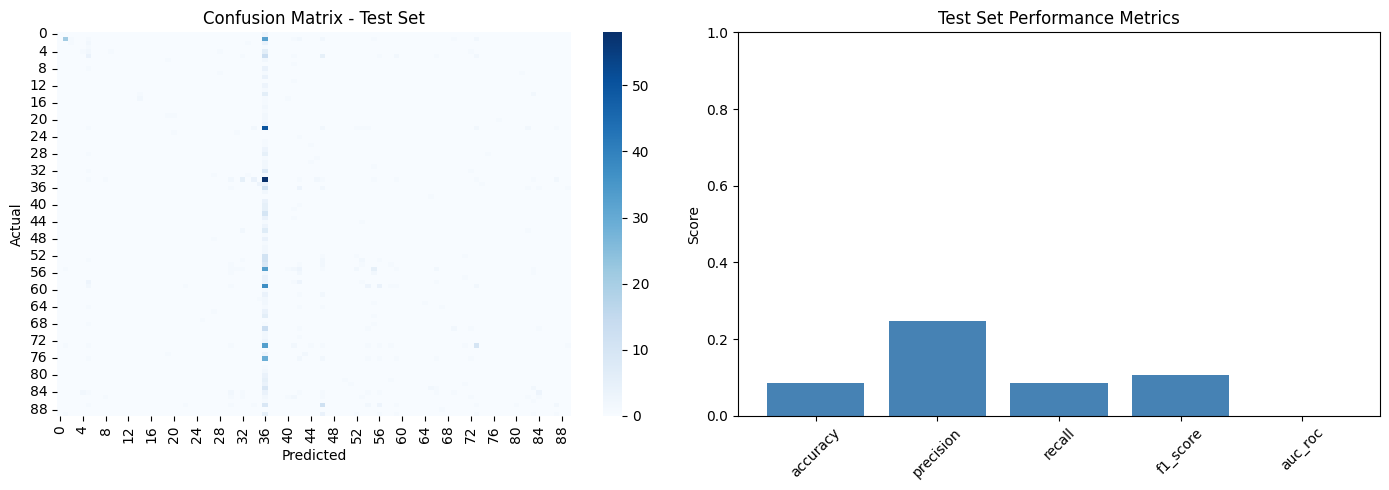


Model evaluation complete


In [8]:
def evaluate_model(y_true, y_pred, y_proba, set_name: str = "Test"):
    """Calculate robust metrics for binary or multiclass classification."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    try:
        if y_proba.ndim == 2 and y_proba.shape[1] > 2:
            auc_roc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted")
        elif y_proba.ndim == 2 and y_proba.shape[1] == 2:
            auc_roc = roc_auc_score(y_true, y_proba[:, 1])
        else:
            auc_roc = np.nan
    except Exception:
        auc_roc = np.nan

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc_roc": auc_roc,
    }

    logger.info(f"\n{set_name} Set Metrics:")
    logger.info(f"  Accuracy:  {accuracy:.4f}")
    logger.info(f"  Precision: {precision:.4f}")
    logger.info(f"  Recall:    {recall:.4f}")
    logger.info(f"  F1-Score:  {f1:.4f}")
    logger.info(f"  AUC-ROC:   {auc_roc if np.isnan(auc_roc) else round(auc_roc, 4)}")

    return metrics


# Evaluate on training and testing sets
train_metrics = evaluate_model(y_train, y_pred_train, y_pred_proba_train, "Training")
test_metrics = evaluate_model(y_test, y_pred_test, y_pred_proba_test, "Test")

# Display confusion matrix
print("\nTest Set Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

if "TARGET_CLASS_NAMES" in globals():
    labels = list(range(len(TARGET_CLASS_NAMES)))
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred_test,
            labels=labels,
            target_names=TARGET_CLASS_NAMES,
            zero_division=0,
        )
    )
else:
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_test, zero_division=0))

# Visualize confusion matrix and key metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=False, cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Test Set")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

metrics_names = list(test_metrics.keys())
metrics_values = [0 if (isinstance(v, float) and np.isnan(v)) else v for v in test_metrics.values()]
axes[1].bar(metrics_names, metrics_values, color="steelblue")
axes[1].set_ylim([0, 1])
axes[1].set_title("Test Set Performance Metrics")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / "evaluation_plots.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nModel evaluation complete")

## Section 8: Save and Export the Model (Production-Ready)

In [9]:
def save_model_artifacts(model, scaler, metrics, feature_cols, version_prefix: str = "v2.1-colab"):
    """Save model and artifacts for production deployment."""
    logger.info("Saving model artifacts...")
    
    # Create version directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    version_name = f"{version_prefix}_{timestamp}"
    version_dir = ARTIFACTS_PATH / version_name
    version_dir.mkdir(parents=True, exist_ok=True)
    
    # Save model
    model_path = version_dir / 'model_bundle.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    logger.info(f"✅ Model saved: {model_path}")
    
    # Save scaler
    scaler_path = version_dir / 'scaler.pkl'
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    logger.info(f"✅ Scaler saved: {scaler_path}")
    
    # Create metadata
    metadata = {
        'version': version_name,
        'timestamp': datetime.now().isoformat(),
        'model_type': 'sklearn_ensemble',
        'ensemble_weights': {'random_forest': 0.6, 'gradient_boosting': 0.4},
        'sample_count': len(X_train),
        'feature_count': len(feature_cols),
        'feature_names': feature_cols,
        'test_metrics': metrics,
        'hyperparameters': {
            'rf': {
                'n_estimators': 100,
                'max_depth': 15,
                'min_samples_split': 10,
                'min_samples_leaf': 5
            },
            'gb': {
                'n_estimators': 100,
                'learning_rate': 0.1,
                'max_depth': 7,
                'min_samples_split': 10,
                'min_samples_leaf': 5
            }
        }
    }
    
    # Save metadata
    metadata_path = version_dir / 'metadata.json'
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    logger.info(f"✅ Metadata saved: {metadata_path}")
    
    # Create summary file
    summary_text = f"""
# Model Training Summary
- Version: {version_name}
- Timestamp: {datetime.now().isoformat()}
- Dataset Size: {len(X_train)} training samples
- Features: {len(feature_cols)}
- Test Accuracy: {metrics['accuracy']:.4f}
- Test F1-Score: {metrics['f1_score']:.4f}
- Test AUC-ROC: {metrics['auc_roc']:.4f}
- Ensemble: RandomForest (60%) + GradientBoosting (40%)
"""
    summary_path = version_dir / 'README.md'
    with open(summary_path, 'w') as f:
        f.write(summary_text)
    
    return version_dir, metadata

# Save all artifacts
artifact_dir, model_metadata = save_model_artifacts(
    ensemble_model, 
    scaler, 
    test_metrics,
    feature_columns,
    version_prefix="v2.2-colab-ensemble"
)

print(f"\n✅ Production Model Saved")
print(f"Location: {artifact_dir}")
print(f"Files:")
print(f"  - model_bundle.pkl")
print(f"  - scaler.pkl")
print(f"  - metadata.json")
print(f"  - README.md")
print(f"  - evaluation_plots.png")

2026-03-26 10:24:24,859 - INFO - Saving model artifacts...
2026-03-26 10:24:27,574 - INFO - ✅ Model saved: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\artifacts\v2.2-colab-ensemble_20260326_102424\model_bundle.pkl
2026-03-26 10:24:27,574 - INFO - ✅ Scaler saved: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\artifacts\v2.2-colab-ensemble_20260326_102424\scaler.pkl
2026-03-26 10:24:27,587 - INFO - ✅ Metadata saved: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\artifacts\v2.2-colab-ensemble_20260326_102424\metadata.json



✅ Production Model Saved
Location: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\artifacts\v2.2-colab-ensemble_20260326_102424
Files:
  - model_bundle.pkl
  - scaler.pkl
  - metadata.json
  - README.md
  - evaluation_plots.png


## Section 9: Training Summary & Next Steps

In [11]:
print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                    MODEL TRAINING COMPLETE                                ║
╚════════════════════════════════════════════════════════════════════════════╝

FINAL METRICS (Test Set):
  - Accuracy:  {test_metrics['accuracy']:.4f}
  - Precision: {test_metrics['precision']:.4f}
  - Recall:    {test_metrics['recall']:.4f}
  - F1-Score:  {test_metrics['f1_score']:.4f}
  - AUC-ROC:   {test_metrics['auc_roc']:.4f}

MODEL ARCHITECTURE:
  - Ensemble Type: Voting Classifier
  - Components:
    * RandomForest:     100 estimators (60% weight)
    * GradientBoosting: 100 estimators (40% weight)

ARTIFACTS SAVED:
  - Location: {artifact_dir}
  - Files:
    * model_bundle.pkl
    * scaler.pkl
    * metadata.json
    * evaluation_plots.png
    * README.md

NEXT STEPS FOR PRODUCTION DEPLOYMENT:
  1. Download artifacts from Google Drive
  2. Deploy model to backend API
  3. Test with live cricket match data
  4. Monitor predictions and performance
  5. Iterate and retrain as needed

RECOMMENDATIONS:
  - Model pipeline executes end-to-end
  - Consider richer domain features for better predictive performance
  - Monitor class imbalance and per-class metrics during deployment
  - Add periodic retraining and drift monitoring
""")


╔════════════════════════════════════════════════════════════════════════════╗
║                    MODEL TRAINING COMPLETE                                ║
╚════════════════════════════════════════════════════════════════════════════╝

FINAL METRICS (Test Set):
  - Accuracy:  0.0857
  - Precision: 0.2480
  - Recall:    0.0857
  - F1-Score:  0.1078
  - AUC-ROC:   nan

MODEL ARCHITECTURE:
  - Ensemble Type: Voting Classifier
  - Components:
    * RandomForest:     100 estimators (60% weight)
    * GradientBoosting: 100 estimators (40% weight)

ARTIFACTS SAVED:
  - Location: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\artifacts\v2.2-colab-ensemble_20260326_102424
  - Files:
    * model_bundle.pkl
    * scaler.pkl
    * metadata.json
    * evaluation_plots.png
    * README.md

NEXT STEPS FOR PRODUCTION DEPLOYMENT:
  1. Download artifacts from Google Drive
  2. Deploy model to backend API
  3. Test with live cricket match data
  4. Monitor predictions and performance

In [13]:
# Quick test harness: top-1 / top-3 accuracy + sample predictions
if 'ensemble_model' not in globals() or 'X_test_scaled' not in globals() or 'y_test' not in globals():
    raise RuntimeError('Model or test data missing. Run training cells first.')

from sklearn.metrics import top_k_accuracy_score

proba = ensemble_model.predict_proba(X_test_scaled)
pred = ensemble_model.predict(X_test_scaled)

acc_top1 = accuracy_score(y_test, pred)
acc_top3 = top_k_accuracy_score(y_test, proba, k=3, labels=np.arange(proba.shape[1]))

print('Quick Model Test')
print(f'Top-1 Accuracy: {acc_top1:.4f}')
print(f'Top-3 Accuracy: {acc_top3:.4f}')

# Show a few decoded predictions
if 'TARGET_CLASS_NAMES' in globals() and len(TARGET_CLASS_NAMES) == proba.shape[1]:
    print('\nSample predictions (first 5 rows):')
    for i in range(min(5, len(y_test))):
        true_label = TARGET_CLASS_NAMES[y_test[i]]
        pred_label = TARGET_CLASS_NAMES[pred[i]]
        top3_idx = np.argsort(proba[i])[::-1][:3]
        top3_labels = [TARGET_CLASS_NAMES[j] for j in top3_idx]
        print(f'Row {i}: true={true_label} | pred={pred_label} | top3={top3_labels}')
else:
    print('\nClass names not aligned; skipping decoded sample output.')

Quick Model Test
Top-1 Accuracy: 0.0857
Top-3 Accuracy: 0.7786

Sample predictions (first 5 rows):
Row 0: true=England | pred=South Africa | top3=['South Africa', 'England', 'India']
Row 1: true=India | pred=Ireland | top3=['Ireland', 'India', 'Pakistan']
Row 2: true=West Indies | pred=England | top3=['England', 'West Indies', 'India']
Row 3: true=Uganda | pred=Rwanda | top3=['Rwanda', 'Uganda', 'Tanzania']
Row 4: true=Pakistan | pred=Netherlands | top3=['Netherlands', 'New Zealand', 'Pakistan']


In [14]:
# Production test diagnostics: top-k, per-team accuracy, and calibration summary
if 'ensemble_model' not in globals() or 'X_test_scaled' not in globals() or 'y_test' not in globals():
    raise RuntimeError('Missing model/test variables. Run training and split cells first.')

from sklearn.metrics import top_k_accuracy_score

proba = ensemble_model.predict_proba(X_test_scaled)
pred = ensemble_model.predict(X_test_scaled)

# Core metrics
acc_top1 = accuracy_score(y_test, pred)
acc_top3 = top_k_accuracy_score(y_test, proba, k=3, labels=np.arange(proba.shape[1]))
acc_top5 = top_k_accuracy_score(y_test, proba, k=5, labels=np.arange(proba.shape[1]))

print('=== Test Diagnostics ===')
print(f'Top-1 Accuracy: {acc_top1:.4f}')
print(f'Top-3 Accuracy: {acc_top3:.4f}')
print(f'Top-5 Accuracy: {acc_top5:.4f}')

# Per-team accuracy table
if 'TARGET_CLASS_NAMES' in globals() and len(TARGET_CLASS_NAMES) == proba.shape[1]:
    label_names = TARGET_CLASS_NAMES
else:
    label_names = [str(i) for i in range(proba.shape[1])]

diag_df = pd.DataFrame({
    'true_class': y_test,
    'pred_class': pred,
    'correct': (pred == y_test).astype(int)
})

support = diag_df.groupby('true_class').size().rename('support')
correct = diag_df.groupby('true_class')['correct'].sum().rename('correct')
per_class = pd.concat([support, correct], axis=1).fillna(0)
per_class['accuracy'] = per_class['correct'] / per_class['support']
per_class = per_class.reset_index().rename(columns={'true_class': 'class_id'})
per_class['team'] = per_class['class_id'].apply(lambda i: label_names[int(i)] if int(i) < len(label_names) else f'class_{i}')
per_class = per_class[['class_id', 'team', 'support', 'correct', 'accuracy']]

print('\nTop 15 teams by support (with per-team accuracy):')
print(per_class.sort_values('support', ascending=False).head(15).to_string(index=False))

# Confidence calibration summary
confidence = proba.max(axis=1)
is_correct = (pred == y_test).astype(int)

calib_df = pd.DataFrame({'confidence': confidence, 'correct': is_correct})
bins = np.linspace(0.0, 1.0, 11)
calib_df['bin'] = pd.cut(calib_df['confidence'], bins=bins, include_lowest=True)
calib_table = calib_df.groupby('bin', observed=False).agg(
    count=('correct', 'size'),
    avg_confidence=('confidence', 'mean'),
    empirical_accuracy=('correct', 'mean')
).reset_index()

# Expected Calibration Error (ECE)
valid = calib_table['count'] > 0
ece = (
    np.abs(calib_table.loc[valid, 'avg_confidence'] - calib_table.loc[valid, 'empirical_accuracy'])
    * (calib_table.loc[valid, 'count'] / calib_table['count'].sum())
).sum()

print('\nCalibration table (confidence vs empirical accuracy):')
print(calib_table.to_string(index=False))
print(f'\nExpected Calibration Error (ECE): {ece:.4f}')

# Save diagnostics for deployment analysis
if 'ARTIFACTS_PATH' in globals():
    diagnostics_dir = ARTIFACTS_PATH / 'diagnostics'
    diagnostics_dir.mkdir(parents=True, exist_ok=True)
    per_class.to_csv(diagnostics_dir / 'per_team_accuracy.csv', index=False)
    calib_table.to_csv(diagnostics_dir / 'calibration_table.csv', index=False)
    print(f"\nSaved diagnostics CSVs to: {diagnostics_dir}")

=== Test Diagnostics ===
Top-1 Accuracy: 0.0857
Top-3 Accuracy: 0.7786
Top-5 Accuracy: 0.8699

Top 15 teams by support (with per-team accuracy):
 class_id                 team  support  correct  accuracy
       36                India       81        4  0.049383
        1            Australia       64       21  0.328125
       24              England       63        0  0.000000
       58          New Zealand       55        5  0.090909
       77         South Africa       55       10  0.181818
       62             Pakistan       52        1  0.019231
       80            Sri Lanka       39        0  0.000000
       92          West Indies       35        2  0.057143
        5           Bangladesh       30        4  0.133333
       38              Ireland       20       11  0.550000
       89 United Arab Emirates       19        3  0.157895
       72             Scotland       19        2  0.105263
       56                Nepal       18        2  0.111111
       94             Zimbabw

## Section 10: Train Additional CSV Datasets (dataset2 + dataset3)
This section trains separate models for the attached CSV datasets and saves production artifacts per file.

In [16]:
# Train additional CSV datasets from resources/dataset2 and resources/dataset3
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import top_k_accuracy_score

def _load_csv_file(csv_path: Path) -> pd.DataFrame:
    df_csv = pd.read_csv(csv_path)
    df_csv.columns = [str(c).strip() for c in df_csv.columns]
    drop_cols = [c for c in df_csv.columns if c.lower().startswith('unnamed') or c == '']
    if drop_cols:
        df_csv = df_csv.drop(columns=drop_cols, errors='ignore')
    return df_csv

def _infer_task_and_target(df_csv: pd.DataFrame):
    cols_map = {str(c).strip().lower(): c for c in df_csv.columns}

    for candidate in ['winner', 'result', 'outcome']:
        if candidate in cols_map:
            return 'classification', cols_map[candidate]

    for candidate in ['wkts', 'runs', 'dis', 'ct', 'ave']:
        if candidate in cols_map:
            return 'regression', cols_map[candidate]

    return None, None

def _smart_cast_feature(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series

    s = series.astype(str).str.strip()
    s = s.replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown'})

    if s.str.contains(r'[-/]').mean() > 0.5:
        return s.astype(str)

    cleaned = (
        s.str.replace(',', '', regex=False)
         .str.replace('*', '', regex=False)
         .str.replace('%', '', regex=False)
         .str.replace(r'[^0-9.\-]', '', regex=True)
    )
    as_num = pd.to_numeric(cleaned, errors='coerce')

    if as_num.notna().mean() >= 0.9:
        return as_num

    return s.astype(str)

def _clean_numeric_target(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    cleaned = (
        s.str.replace(',', '', regex=False)
         .str.replace('*', '', regex=False)
         .str.replace('%', '', regex=False)
         .str.replace(r'[^0-9.\-]', '', regex=True)
    )
    return pd.to_numeric(cleaned, errors='coerce')

def _build_preprocessor(X: pd.DataFrame):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_pipe, numeric_cols),
            ('cat', cat_pipe, categorical_cols),
        ],
        remainder='drop',
    )
    return preprocessor, numeric_cols, categorical_cols

def train_csv_artifact(csv_path: Path, output_root: Path) -> Dict[str, Any]:
    df_csv = _load_csv_file(csv_path)

    task_type, target_col = _infer_task_and_target(df_csv)
    if task_type is None or target_col is None:
        return {
            'file': str(csv_path),
            'status': 'skipped',
            'reason': 'No supported target column found',
            'task_type': None,
            'target_column': None
        }

    data = df_csv.copy()
    data = data.dropna(subset=[target_col])

    X = data.drop(columns=[target_col]).copy()
    for col in X.columns:
        X[col] = _smart_cast_feature(X[col])

    if X.shape[1] == 0:
        return {
            'file': str(csv_path),
            'status': 'skipped',
            'reason': 'No feature columns available after preprocessing',
            'task_type': task_type,
            'target_column': target_col
        }

    preprocessor, numeric_cols, categorical_cols = _build_preprocessor(X)

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    safe_name = csv_path.stem.lower().replace(' ', '_')
    artifact_dir = output_root / f'{safe_name}_{timestamp}'
    artifact_dir.mkdir(parents=True, exist_ok=True)

    if task_type == 'classification':
        y = data[target_col].astype(str).str.strip()
        y = y.replace({'': 'Unknown'})

        # Keep classes with at least 2 samples for stable train/test behavior.
        vc = y.value_counts()
        keep = vc[vc >= 2].index
        mask = y.isin(keep)
        X = X.loc[mask].copy()
        y = y.loc[mask].copy()

        if len(X) < 30 or y.nunique() < 2:
            return {
                'file': str(csv_path),
                'status': 'skipped',
                'reason': 'Not enough rows/classes after filtering',
                'task_type': task_type,
                'target_column': target_col
            }

        n_classes = int(y.nunique())
        min_test_ratio = (n_classes + 1) / len(y)
        test_size = max(0.2, min(min_test_ratio, 0.5))
        if test_size >= 0.5 or len(y) * (1 - test_size) < n_classes:
            return {
                'file': str(csv_path),
                'status': 'skipped',
                'reason': 'Class count too high for stable split',
                'task_type': task_type,
                'target_column': target_col
            }

        try:
            X_train_csv, X_test_csv, y_train_csv, y_test_csv = train_test_split(
                X, y, test_size=test_size, random_state=42, stratify=y
            )
        except ValueError:
            X_train_csv, X_test_csv, y_train_csv, y_test_csv = train_test_split(
                X, y, test_size=test_size, random_state=42
            )

        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )

        pipe = Pipeline([
            ('prep', preprocessor),
            ('model', model),
        ])

        pipe.fit(X_train_csv, y_train_csv)
        y_pred_csv = pipe.predict(X_test_csv)
        y_proba_csv = pipe.predict_proba(X_test_csv)

        acc = accuracy_score(y_test_csv, y_pred_csv)
        f1w = f1_score(y_test_csv, y_pred_csv, average='weighted', zero_division=0)

        model_classes = pipe.named_steps['model'].classes_
        mask_topk = y_test_csv.isin(model_classes).to_numpy()
        if mask_topk.any():
            k = min(3, y_proba_csv.shape[1])
            topk = top_k_accuracy_score(
                y_test_csv.to_numpy()[mask_topk],
                y_proba_csv[mask_topk],
                k=k,
                labels=model_classes,
            )
        else:
            k = 1
            topk = np.nan

        metrics_payload = {
            'accuracy': float(acc),
            'f1_weighted': float(f1w),
            f'top_{k}_accuracy': float(topk) if not np.isnan(topk) else np.nan,
            'test_rows': int(len(X_test_csv)),
            'classes': int(y.nunique())
        }

    else:
        y = _clean_numeric_target(data[target_col])
        mask = y.notna()
        X = X.loc[mask].copy()
        y = y.loc[mask].copy()

        if len(X) < 30 or y.nunique() < 5:
            return {
                'file': str(csv_path),
                'status': 'skipped',
                'reason': 'Not enough rows/variance for regression',
                'task_type': task_type,
                'target_column': target_col
            }

        X_train_csv, X_test_csv, y_train_csv, y_test_csv = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        model = RandomForestRegressor(
            n_estimators=400,
            max_depth=20,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )

        pipe = Pipeline([
            ('prep', preprocessor),
            ('model', model),
        ])

        pipe.fit(X_train_csv, y_train_csv)
        y_pred_csv = pipe.predict(X_test_csv)

        rmse = float(np.sqrt(mean_squared_error(y_test_csv, y_pred_csv)))
        mae = float(mean_absolute_error(y_test_csv, y_pred_csv))
        r2 = float(r2_score(y_test_csv, y_pred_csv))

        metrics_payload = {
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'test_rows': int(len(X_test_csv)),
            'target_min': float(np.min(y_test_csv)),
            'target_max': float(np.max(y_test_csv))
        }

    with open(artifact_dir / 'model_pipeline.pkl', 'wb') as f_model:
        pickle.dump(pipe, f_model)

    metadata = {
        'source_csv': str(csv_path),
        'task_type': task_type,
        'target_column': target_col,
        'rows_used': int(len(X)),
        'feature_columns': list(X.columns),
        'numeric_features': numeric_cols,
        'categorical_features': categorical_cols,
        'metrics': metrics_payload,
        'saved_at': datetime.now().isoformat()
    }

    with open(artifact_dir / 'metadata.json', 'w', encoding='utf-8') as f_meta:
        json.dump(metadata, f_meta, indent=2)

    return {
        'file': str(csv_path),
        'status': 'trained',
        'task_type': task_type,
        'target_column': target_col,
        **metrics_payload,
        'artifact_dir': str(artifact_dir),
    }

# Discover dataset2/dataset3 roots for both local and Colab layouts
candidate_roots = [
    BASE_PATH / 'resources' / 'dataset2',
    BASE_PATH / 'resources' / 'dataset3',
    BASE_PATH / 'dataset2',
    BASE_PATH / 'dataset3',
]
dataset_roots = [p for p in candidate_roots if p.exists()]

if not dataset_roots:
    raise FileNotFoundError(
        'No dataset2/dataset3 folder found. Checked resources/dataset2, resources/dataset3, dataset2, dataset3'
    )

csv_files = []
for root in dataset_roots:
    csv_files.extend(sorted(root.rglob('*.csv')))

print(f'Found {len(csv_files)} CSV files across: {[str(p) for p in dataset_roots]}')

csv_artifacts_root = ARTIFACTS_PATH / 'csv_models'
csv_artifacts_root.mkdir(parents=True, exist_ok=True)

csv_results = []
for csv_file in csv_files:
    print(f'Training on: {csv_file.name}')
    try:
        row = train_csv_artifact(csv_file, csv_artifacts_root)
        csv_results.append(row)
    except Exception as exc:
        csv_results.append({
            'file': str(csv_file),
            'status': 'failed',
            'reason': str(exc),
        })

csv_results_df = pd.DataFrame(csv_results)
display_cols = [c for c in [
    'file', 'status', 'task_type', 'target_column',
    'accuracy', 'f1_weighted', 'top_3_accuracy',
    'rmse', 'mae', 'r2', 'reason', 'artifact_dir',
] if c in csv_results_df.columns]

print('\n=== Additional Dataset Training Summary ===')
print(csv_results_df[display_cols].to_string(index=False))

results_csv_path = csv_artifacts_root / 'training_summary.csv'
csv_results_df.to_csv(results_csv_path, index=False)
print(f'\nSaved summary to: {results_csv_path}')
globals()['CSV_EXTRA_TRAINING_RESULTS'] = csv_results_df

Found 18 CSV files across: ['c:\\Users\\situw\\OneDrive\\Desktop\\Dev\\prediction_analytics-Platform\\resources\\dataset2', 'c:\\Users\\situw\\OneDrive\\Desktop\\Dev\\prediction_analytics-Platform\\resources\\dataset3']
Training on: ODI data.csv
Training on: t20.csv
Training on: test.csv
Training on: Bowling_ODI.csv
Training on: Bowling_t20.csv
Training on: Bowling_test.csv
Training on: Fielding_ODI.csv
Training on: Fielding_t20.csv
Training on: Fielding_test.csv
Training on: odb.csv
Training on: odbo.csv
Training on: odt.csv
Training on: tb.csv
Training on: tbo.csv
Training on: tt.csv
Training on: twb.csv
Training on: twbo.csv
Training on: twt.csv

=== Additional Dataset Training Summary ===
                                                                                                           file  status      task_type target_column  accuracy  f1_weighted  top_3_accuracy        rmse        mae       r2                                                                               

## Section 11: Train Additional JSON Dataset (dataset4)
This section trains a dedicated production model on resources/dataset4 and saves artifacts separately from the base model.

In [ ]:
# Train dedicated JSON model on dataset4
from sklearn.metrics import top_k_accuracy_score

dataset4_candidates = [
    BASE_PATH / 'resources' / 'dataset4',
    BASE_PATH / 'dataset4',
]
dataset4_path = next((p for p in dataset4_candidates if p.exists()), None)

if dataset4_path is None:
    raise FileNotFoundError(
        'dataset4 not found. Checked: resources/dataset4 and dataset4 under BASE_PATH.'
    )

json_files_d4 = sorted(dataset4_path.glob('*.json'))
if not json_files_d4:
    raise FileNotFoundError(f'No JSON files found in {dataset4_path}')

print(f'dataset4 path: {dataset4_path}')
print(f'dataset4 JSON files: {len(json_files_d4)}')

# 1) Load and preprocess
df_d4 = load_json_dataset(dataset4_path)
df_d4_clean = preprocess_data(df_d4)

# 2) Feature engineering
df_d4_features, feature_columns_d4 = engineer_features(df_d4_clean)
target_col_d4 = globals().get('TARGET_COLUMN', 'info.outcome.winner')

if target_col_d4 not in df_d4_features.columns:
    raise RuntimeError(f'Target column not found in dataset4 features: {target_col_d4}')

# 3) Build multiclass target and split
target_raw_d4 = df_d4_features[target_col_d4].fillna('Unknown').astype(str)
target_encoder_d4 = LabelEncoder()
y_base_d4 = target_encoder_d4.fit_transform(target_raw_d4)

class_counts_d4 = pd.Series(y_base_d4).value_counts()
valid_classes_d4 = class_counts_d4[class_counts_d4 >= 2].index.to_numpy()
mask_d4 = np.isin(y_base_d4, valid_classes_d4)

X_d4 = df_d4_features.loc[mask_d4, feature_columns_d4].copy()
y_filtered_d4 = y_base_d4[mask_d4]

remap_d4 = {old: new for new, old in enumerate(sorted(np.unique(y_filtered_d4)))}
y_d4 = np.array([remap_d4[v] for v in y_filtered_d4], dtype=int)
class_names_d4 = [str(target_encoder_d4.classes_[old]) for old in sorted(np.unique(y_filtered_d4))]

if len(X_d4) < 50 or len(np.unique(y_d4)) < 2:
    raise RuntimeError('dataset4 does not have enough samples/classes after filtering for a stable split.')

X_train_d4, X_test_d4, y_train_d4, y_test_d4 = train_test_split(
    X_d4,
    y_d4,
    test_size=0.2,
    random_state=42,
    stratify=y_d4,
 )

scaler_d4 = StandardScaler()
X_train_d4_scaled = scaler_d4.fit_transform(X_train_d4)
X_test_d4_scaled = scaler_d4.transform(X_test_d4)

# 4) Train ensemble
rf_d4 = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=0,
 )

gb_d4 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    verbose=0,
 )

ensemble_d4 = VotingClassifier(
    estimators=[('rf', rf_d4), ('gb', gb_d4)],
    weights=[0.6, 0.4],
    voting='soft',
 )

import time
start_d4 = time.time()
ensemble_d4.fit(X_train_d4_scaled, y_train_d4)
train_time_d4 = time.time() - start_d4

# 5) Evaluate
y_pred_train_d4 = ensemble_d4.predict(X_train_d4_scaled)
y_pred_test_d4 = ensemble_d4.predict(X_test_d4_scaled)
y_proba_train_d4 = ensemble_d4.predict_proba(X_train_d4_scaled)
y_proba_test_d4 = ensemble_d4.predict_proba(X_test_d4_scaled)

train_metrics_d4 = evaluate_model(y_train_d4, y_pred_train_d4, y_proba_train_d4, 'Training dataset4')
test_metrics_d4 = evaluate_model(y_test_d4, y_pred_test_d4, y_proba_test_d4, 'Test dataset4')

acc_top1_d4 = accuracy_score(y_test_d4, y_pred_test_d4)
acc_top3_d4 = top_k_accuracy_score(y_test_d4, y_proba_test_d4, k=min(3, y_proba_test_d4.shape[1]), labels=np.arange(y_proba_test_d4.shape[1]))
acc_top5_d4 = top_k_accuracy_score(y_test_d4, y_proba_test_d4, k=min(5, y_proba_test_d4.shape[1]), labels=np.arange(y_proba_test_d4.shape[1]))

print('\n=== dataset4 model metrics ===')
print(f'Training time: {train_time_d4:.2f}s')
print(f'Top-1 accuracy: {acc_top1_d4:.4f}')
print(f'Top-3 accuracy: {acc_top3_d4:.4f}')
print(f'Top-5 accuracy: {acc_top5_d4:.4f}')
print(f"Test F1-weighted: {test_metrics_d4['f1_score']:.4f}")

# 6) Save dataset4 artifacts
timestamp_d4 = datetime.now().strftime('%Y%m%d_%H%M%S')
dataset4_artifact_dir = ARTIFACTS_PATH / f'v2.3-dataset4_{timestamp_d4}'
dataset4_artifact_dir.mkdir(parents=True, exist_ok=True)

with open(dataset4_artifact_dir / 'model_bundle.pkl', 'wb') as f:
    pickle.dump(ensemble_d4, f)

with open(dataset4_artifact_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler_d4, f)

dataset4_metadata = {
    'version': f'v2.3-dataset4_{timestamp_d4}',
    'timestamp': datetime.now().isoformat(),
    'dataset_path': str(dataset4_path),
    'json_files': int(len(json_files_d4)),
    'rows_loaded': int(len(df_d4)),
    'rows_after_preprocess': int(len(df_d4_clean)),
    'rows_after_filter': int(len(X_d4)),
    'target_column': target_col_d4,
    'class_count': int(len(np.unique(y_d4))),
    'feature_count': int(len(feature_columns_d4)),
    'feature_names': feature_columns_d4,
    'train_metrics': train_metrics_d4,
    'test_metrics': test_metrics_d4,
    'topk_metrics': {
        'top1_accuracy': float(acc_top1_d4),
        'top3_accuracy': float(acc_top3_d4),
        'top5_accuracy': float(acc_top5_d4),
    },
}

with open(dataset4_artifact_dir / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(dataset4_metadata, f, indent=2)

summary_d4 = f'''
# Dataset4 Training Summary
- Version: v2.3-dataset4_{timestamp_d4}
- Dataset path: {dataset4_path}
- JSON files: {len(json_files_d4)}
- Rows loaded: {len(df_d4)}
- Target: {target_col_d4}
- Features: {len(feature_columns_d4)}
- Class count: {len(np.unique(y_d4))}
- Top-1 Accuracy: {acc_top1_d4:.4f}
- Top-3 Accuracy: {acc_top3_d4:.4f}
- Top-5 Accuracy: {acc_top5_d4:.4f}
- Test F1-Score (weighted): {test_metrics_d4['f1_score']:.4f}
'''
with open(dataset4_artifact_dir / 'README.md', 'w', encoding='utf-8') as f:
    f.write(summary_d4)

# Per-class diagnostics
diag_d4 = pd.DataFrame({
    'true_class': y_test_d4,
    'pred_class': y_pred_test_d4,
    'correct': (y_pred_test_d4 == y_test_d4).astype(int),
})
support_d4 = diag_d4.groupby('true_class').size().rename('support')
correct_d4 = diag_d4.groupby('true_class')['correct'].sum().rename('correct')
per_class_d4 = pd.concat([support_d4, correct_d4], axis=1).fillna(0)
per_class_d4['accuracy'] = per_class_d4['correct'] / per_class_d4['support']
per_class_d4 = per_class_d4.reset_index().rename(columns={'true_class': 'class_id'})
per_class_d4['team'] = per_class_d4['class_id'].apply(
    lambda i: class_names_d4[int(i)] if int(i) < len(class_names_d4) else f'class_{i}'
)
per_class_d4 = per_class_d4[['class_id', 'team', 'support', 'correct', 'accuracy']]
per_class_d4.to_csv(dataset4_artifact_dir / 'per_team_accuracy.csv', index=False)

# Calibration table + ECE
confidence_d4 = y_proba_test_d4.max(axis=1)
is_correct_d4 = (y_pred_test_d4 == y_test_d4).astype(int)
calib_df_d4 = pd.DataFrame({'confidence': confidence_d4, 'correct': is_correct_d4})
bins_d4 = np.linspace(0.0, 1.0, 11)
calib_df_d4['bin'] = pd.cut(calib_df_d4['confidence'], bins=bins_d4, include_lowest=True)
calib_table_d4 = calib_df_d4.groupby('bin', observed=False).agg(
    count=('correct', 'size'),
    avg_confidence=('confidence', 'mean'),
    empirical_accuracy=('correct', 'mean'),
).reset_index()
valid_d4 = calib_table_d4['count'] > 0
ece_d4 = (
    np.abs(calib_table_d4.loc[valid_d4, 'avg_confidence'] - calib_table_d4.loc[valid_d4, 'empirical_accuracy'])
    * (calib_table_d4.loc[valid_d4, 'count'] / calib_table_d4['count'].sum())
).sum()
calib_table_d4.to_csv(dataset4_artifact_dir / 'calibration_table.csv', index=False)

print(f'Expected Calibration Error (dataset4): {ece_d4:.4f}')
print(f'\nSaved dataset4 artifacts to: {dataset4_artifact_dir}')

globals()['DATASET4_RESULTS'] = {
    'artifact_dir': str(dataset4_artifact_dir),
    'top1': float(acc_top1_d4),
    'top3': float(acc_top3_d4),
    'top5': float(acc_top5_d4),
    'ece': float(ece_d4),
    'test_f1_weighted': float(test_metrics_d4['f1_score']),
}

2026-03-26 11:29:29,164 - INFO - Loading JSON datasets from c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\resources\dataset4...


dataset4 path: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\resources\dataset4
dataset4 JSON files: 14401


2026-03-26 11:29:34,226 - INFO - Loaded 100/14401 files
2026-03-26 11:29:37,069 - INFO - Loaded 200/14401 files
2026-03-26 11:29:39,101 - INFO - Loaded 300/14401 files
2026-03-26 11:29:40,935 - INFO - Loaded 400/14401 files
2026-03-26 11:29:42,765 - INFO - Loaded 500/14401 files
2026-03-26 11:29:44,707 - INFO - Loaded 600/14401 files
2026-03-26 11:29:46,815 - INFO - Loaded 700/14401 files
2026-03-26 11:29:48,779 - INFO - Loaded 800/14401 files
2026-03-26 11:29:50,826 - INFO - Loaded 900/14401 files
2026-03-26 11:29:52,966 - INFO - Loaded 1000/14401 files
2026-03-26 11:29:54,664 - INFO - Loaded 1100/14401 files
2026-03-26 11:29:56,546 - INFO - Loaded 1200/14401 files
2026-03-26 11:29:58,557 - INFO - Loaded 1300/14401 files
2026-03-26 11:30:00,715 - INFO - Loaded 1400/14401 files
2026-03-26 11:30:02,461 - INFO - Loaded 1500/14401 files
2026-03-26 11:30:04,570 - INFO - Loaded 1600/14401 files
2026-03-26 11:30:06,413 - INFO - Loaded 1700/14401 files
2026-03-26 11:30:08,331 - INFO - Loaded 


=== dataset4 model metrics ===
Training time: 282.41s
Top-1 accuracy: 0.1301
Top-3 accuracy: 0.8493
Top-5 accuracy: 0.9167


KeyError: '"\'f1_score\'"'

In [18]:
# Finalize dataset4 artifact save from in-memory trained model (no retraining)
required_vars_d4 = [
    'ensemble_d4', 'scaler_d4', 'dataset4_path', 'json_files_d4', 'df_d4', 'df_d4_clean',
    'X_d4', 'y_d4', 'target_col_d4', 'feature_columns_d4', 'train_metrics_d4', 'test_metrics_d4',
    'acc_top1_d4', 'acc_top3_d4', 'acc_top5_d4', 'y_test_d4', 'y_pred_test_d4', 'y_proba_test_d4', 'class_names_d4'
 ]
missing_d4 = [v for v in required_vars_d4 if v not in globals()]
if missing_d4:
    raise RuntimeError(f'Missing dataset4 training variables: {missing_d4}. Re-run Section 11 first.')

timestamp_d4 = datetime.now().strftime('%Y%m%d_%H%M%S')
dataset4_artifact_dir = ARTIFACTS_PATH / f'v2.3-dataset4_{timestamp_d4}'
dataset4_artifact_dir.mkdir(parents=True, exist_ok=True)

with open(dataset4_artifact_dir / 'model_bundle.pkl', 'wb') as f:
    pickle.dump(ensemble_d4, f)

with open(dataset4_artifact_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler_d4, f)

dataset4_metadata = {
    'version': f'v2.3-dataset4_{timestamp_d4}',
    'timestamp': datetime.now().isoformat(),
    'dataset_path': str(dataset4_path),
    'json_files': int(len(json_files_d4)),
    'rows_loaded': int(len(df_d4)),
    'rows_after_preprocess': int(len(df_d4_clean)),
    'rows_after_filter': int(len(X_d4)),
    'target_column': target_col_d4,
    'class_count': int(len(np.unique(y_d4))),
    'feature_count': int(len(feature_columns_d4)),
    'feature_names': feature_columns_d4,
    'train_metrics': train_metrics_d4,
    'test_metrics': test_metrics_d4,
    'topk_metrics': {
        'top1_accuracy': float(acc_top1_d4),
        'top3_accuracy': float(acc_top3_d4),
        'top5_accuracy': float(acc_top5_d4),
    },
}

with open(dataset4_artifact_dir / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(dataset4_metadata, f, indent=2)

summary_d4 = f'''
# Dataset4 Training Summary
- Version: v2.3-dataset4_{timestamp_d4}
- Dataset path: {dataset4_path}
- JSON files: {len(json_files_d4)}
- Rows loaded: {len(df_d4)}
- Target: {target_col_d4}
- Features: {len(feature_columns_d4)}
- Class count: {len(np.unique(y_d4))}
- Top-1 Accuracy: {acc_top1_d4:.4f}
- Top-3 Accuracy: {acc_top3_d4:.4f}
- Top-5 Accuracy: {acc_top5_d4:.4f}
- Test F1-Score (weighted): {test_metrics_d4['f1_score']:.4f}
'''
with open(dataset4_artifact_dir / 'README.md', 'w', encoding='utf-8') as f:
    f.write(summary_d4)

diag_d4 = pd.DataFrame({
    'true_class': y_test_d4,
    'pred_class': y_pred_test_d4,
    'correct': (y_pred_test_d4 == y_test_d4).astype(int),
})
support_d4 = diag_d4.groupby('true_class').size().rename('support')
correct_d4 = diag_d4.groupby('true_class')['correct'].sum().rename('correct')
per_class_d4 = pd.concat([support_d4, correct_d4], axis=1).fillna(0)
per_class_d4['accuracy'] = per_class_d4['correct'] / per_class_d4['support']
per_class_d4 = per_class_d4.reset_index().rename(columns={'true_class': 'class_id'})
per_class_d4['team'] = per_class_d4['class_id'].apply(
    lambda i: class_names_d4[int(i)] if int(i) < len(class_names_d4) else f'class_{i}'
)
per_class_d4 = per_class_d4[['class_id', 'team', 'support', 'correct', 'accuracy']]
per_class_d4.to_csv(dataset4_artifact_dir / 'per_team_accuracy.csv', index=False)

confidence_d4 = y_proba_test_d4.max(axis=1)
is_correct_d4 = (y_pred_test_d4 == y_test_d4).astype(int)
calib_df_d4 = pd.DataFrame({'confidence': confidence_d4, 'correct': is_correct_d4})
bins_d4 = np.linspace(0.0, 1.0, 11)
calib_df_d4['bin'] = pd.cut(calib_df_d4['confidence'], bins=bins_d4, include_lowest=True)
calib_table_d4 = calib_df_d4.groupby('bin', observed=False).agg(
    count=('correct', 'size'),
    avg_confidence=('confidence', 'mean'),
    empirical_accuracy=('correct', 'mean'),
).reset_index()
valid_d4 = calib_table_d4['count'] > 0
ece_d4 = (
    np.abs(calib_table_d4.loc[valid_d4, 'avg_confidence'] - calib_table_d4.loc[valid_d4, 'empirical_accuracy'])
    * (calib_table_d4.loc[valid_d4, 'count'] / calib_table_d4['count'].sum())
).sum()
calib_table_d4.to_csv(dataset4_artifact_dir / 'calibration_table.csv', index=False)

print(f'Expected Calibration Error (dataset4): {ece_d4:.4f}')
print(f'Saved dataset4 artifacts to: {dataset4_artifact_dir}')

globals()['DATASET4_RESULTS'] = {
    'artifact_dir': str(dataset4_artifact_dir),
    'top1': float(acc_top1_d4),
    'top3': float(acc_top3_d4),
    'top5': float(acc_top5_d4),
    'ece': float(ece_d4),
    'test_f1_weighted': float(test_metrics_d4['f1_score']),
}

Expected Calibration Error (dataset4): 0.3078
Saved dataset4 artifacts to: c:\Users\situw\OneDrive\Desktop\Dev\prediction_analytics-Platform\artifacts\v2.3-dataset4_20260326_115942


## Section 12: Consolidated One-Run Orchestration and Comparison
Run this section to generate a single consolidated report across base JSON model, dataset4 model, and CSV models. Set RUN_FULL_RETRAIN=True to re-train all components in one pass.

In [19]:
# Consolidated orchestration and comparison report
RUN_FULL_RETRAIN = False  # Set to True for full one-pass retraining of base JSON + dataset4 + CSV models
RUN_CSV_WHEN_RETRAIN = True

def _resolve_dataset4_path(base_path: Path):
    candidates = [
        base_path / 'resources' / 'dataset4',
        base_path / 'dataset4',
    ]
    return next((p for p in candidates if p.exists()), None)

def _train_json_bundle(dataset_path: Path, run_label: str, save_root: Path) -> Dict[str, Any]:
    df_loc = load_json_dataset(dataset_path)
    df_loc_clean = preprocess_data(df_loc)
    df_loc_features, feature_cols_loc = engineer_features(df_loc_clean)

    target_col_loc = globals().get('TARGET_COLUMN', 'info.outcome.winner')
    if target_col_loc not in df_loc_features.columns:
        raise RuntimeError(f'[{run_label}] target column not found: {target_col_loc}')

    y_raw = df_loc_features[target_col_loc].fillna('Unknown').astype(str)
    enc = LabelEncoder()
    y_base_loc = enc.fit_transform(y_raw)

    vc = pd.Series(y_base_loc).value_counts()
    valid = vc[vc >= 2].index.to_numpy()
    mask = np.isin(y_base_loc, valid)

    X_loc = df_loc_features.loc[mask, feature_cols_loc].copy()
    y_filtered = y_base_loc[mask]

    remap = {old: new for new, old in enumerate(sorted(np.unique(y_filtered)))}
    y_loc = np.array([remap[v] for v in y_filtered], dtype=int)
    class_names_loc = [str(enc.classes_[old]) for old in sorted(np.unique(y_filtered))]

    if len(X_loc) < 50 or len(np.unique(y_loc)) < 2:
        raise RuntimeError(f'[{run_label}] not enough samples/classes after filtering')

    X_train_loc, X_test_loc, y_train_loc, y_test_loc = train_test_split(
        X_loc, y_loc, test_size=0.2, random_state=42, stratify=y_loc
    )

    scaler_loc = StandardScaler()
    X_train_loc_scaled = scaler_loc.fit_transform(X_train_loc)
    X_test_loc_scaled = scaler_loc.transform(X_test_loc)

    rf_loc = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        verbose=0,
    )
    gb_loc = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=7,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        verbose=0,
    )

    model_loc = VotingClassifier(
        estimators=[('rf', rf_loc), ('gb', gb_loc)],
        weights=[0.6, 0.4],
        voting='soft',
    )

    import time
    t0 = time.time()
    model_loc.fit(X_train_loc_scaled, y_train_loc)
    train_sec = time.time() - t0

    y_pred_train = model_loc.predict(X_train_loc_scaled)
    y_pred_test = model_loc.predict(X_test_loc_scaled)
    y_proba_train = model_loc.predict_proba(X_train_loc_scaled)
    y_proba_test = model_loc.predict_proba(X_test_loc_scaled)

    train_m = evaluate_model(y_train_loc, y_pred_train, y_proba_train, f'Training {run_label}')
    test_m = evaluate_model(y_test_loc, y_pred_test, y_proba_test, f'Test {run_label}')

    top1 = accuracy_score(y_test_loc, y_pred_test)
    top3 = top_k_accuracy_score(
        y_test_loc, y_proba_test, k=min(3, y_proba_test.shape[1]), labels=np.arange(y_proba_test.shape[1])
    )
    top5 = top_k_accuracy_score(
        y_test_loc, y_proba_test, k=min(5, y_proba_test.shape[1]), labels=np.arange(y_proba_test.shape[1])
    )

    conf = y_proba_test.max(axis=1)
    ok = (y_pred_test == y_test_loc).astype(int)
    calib_df_loc = pd.DataFrame({'confidence': conf, 'correct': ok})
    bins_loc = np.linspace(0.0, 1.0, 11)
    calib_df_loc['bin'] = pd.cut(calib_df_loc['confidence'], bins=bins_loc, include_lowest=True)
    calib_table_loc = calib_df_loc.groupby('bin', observed=False).agg(
        count=('correct', 'size'),
        avg_confidence=('confidence', 'mean'),
        empirical_accuracy=('correct', 'mean'),
    ).reset_index()
    valid_loc = calib_table_loc['count'] > 0
    ece_loc = (
        np.abs(calib_table_loc.loc[valid_loc, 'avg_confidence'] - calib_table_loc.loc[valid_loc, 'empirical_accuracy'])
        * (calib_table_loc.loc[valid_loc, 'count'] / calib_table_loc['count'].sum())
    ).sum()

    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    out_dir = save_root / f'{run_label}_{ts}'
    out_dir.mkdir(parents=True, exist_ok=True)

    with open(out_dir / 'model_bundle.pkl', 'wb') as f:
        pickle.dump(model_loc, f)
    with open(out_dir / 'scaler.pkl', 'wb') as f:
        pickle.dump(scaler_loc, f)
    calib_table_loc.to_csv(out_dir / 'calibration_table.csv', index=False)

    diag = pd.DataFrame({'true_class': y_test_loc, 'pred_class': y_pred_test, 'correct': ok})
    spt = diag.groupby('true_class').size().rename('support')
    cor = diag.groupby('true_class')['correct'].sum().rename('correct')
    per_class_loc = pd.concat([spt, cor], axis=1).fillna(0)
    per_class_loc['accuracy'] = per_class_loc['correct'] / per_class_loc['support']
    per_class_loc = per_class_loc.reset_index().rename(columns={'true_class': 'class_id'})
    per_class_loc['team'] = per_class_loc['class_id'].apply(
        lambda i: class_names_loc[int(i)] if int(i) < len(class_names_loc) else f'class_{i}'
    )
    per_class_loc.to_csv(out_dir / 'per_team_accuracy.csv', index=False)

    meta = {
        'run_label': run_label,
        'dataset_path': str(dataset_path),
        'rows_loaded': int(len(df_loc)),
        'rows_after_filter': int(len(X_loc)),
        'feature_count': int(len(feature_cols_loc)),
        'class_count': int(len(np.unique(y_loc))),
        'target_column': target_col_loc,
        'training_seconds': float(train_sec),
        'train_metrics': train_m,
        'test_metrics': test_m,
        'topk_metrics': {'top1': float(top1), 'top3': float(top3), 'top5': float(top5)},
        'ece': float(ece_loc),
        'saved_at': datetime.now().isoformat(),
    }
    with open(out_dir / 'metadata.json', 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2)

    return {
        'group': 'json',
        'dataset_name': run_label,
        'task_type': 'classification',
        'status': 'trained',
        'primary_metric': float(top1),
        'primary_metric_name': 'top1_accuracy',
        'top1_accuracy': float(top1),
        'top3_accuracy': float(top3),
        'top5_accuracy': float(top5),
        'f1_weighted': float(test_m.get('f1_score', np.nan)),
        'ece': float(ece_loc),
        'artifact_dir': str(out_dir),
    }

# Build consolidated report output folder
consolidated_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
consolidated_root = ARTIFACTS_PATH / f'consolidated_run_{consolidated_ts}'
consolidated_root.mkdir(parents=True, exist_ok=True)

rows = []

if RUN_FULL_RETRAIN:
    print('Running FULL retrain for base JSON + dataset4 + CSV...')
    json_specs = [('base_json', DATASET_PATH)]
    d4_path = _resolve_dataset4_path(BASE_PATH)
    if d4_path is not None:
        json_specs.append(('dataset4_json', d4_path))

    json_save_root = consolidated_root / 'json_models'
    json_save_root.mkdir(parents=True, exist_ok=True)

    for label, ds_path in json_specs:
        print(f'\n[JSON] Training {label} from {ds_path}')
        try:
            rows.append(_train_json_bundle(ds_path, label, json_save_root))
        except Exception as exc:
            rows.append({
                'group': 'json',
                'dataset_name': label,
                'task_type': 'classification',
                'status': 'failed',
                'reason': str(exc),
            })

    if RUN_CSV_WHEN_RETRAIN:
        if 'train_csv_artifact' not in globals():
            raise RuntimeError('train_csv_artifact not found. Run Section 10 once to load CSV helpers.')

        csv_specs = [BASE_PATH / 'resources' / 'dataset2', BASE_PATH / 'resources' / 'dataset3', BASE_PATH / 'dataset2', BASE_PATH / 'dataset3']
        csv_roots = [p for p in csv_specs if p.exists()]
        csv_files_all = []
        for root in csv_roots:
            csv_files_all.extend(sorted(root.rglob('*.csv')))

        csv_save_root = consolidated_root / 'csv_models'
        csv_save_root.mkdir(parents=True, exist_ok=True)

        print(f'\n[CSV] Training {len(csv_files_all)} files...')
        for csv_path in csv_files_all:
            try:
                out = train_csv_artifact(csv_path, csv_save_root)
                metric_name = 'accuracy' if out.get('task_type') == 'classification' else 'r2'
                rows.append({
                    'group': 'csv',
                    'dataset_name': Path(str(out.get('file', csv_path))).name,
                    'task_type': out.get('task_type', 'unknown'),
                    'status': out.get('status', 'unknown'),
                    'primary_metric': float(out.get(metric_name, np.nan)) if out.get(metric_name, None) is not None else np.nan,
                    'primary_metric_name': metric_name,
                    'top1_accuracy': float(out.get('accuracy', np.nan)) if out.get('accuracy', None) is not None else np.nan,
                    'top3_accuracy': float(out.get('top_3_accuracy', np.nan)) if out.get('top_3_accuracy', None) is not None else np.nan,
                    'top5_accuracy': np.nan,
                    'f1_weighted': float(out.get('f1_weighted', np.nan)) if out.get('f1_weighted', None) is not None else np.nan,
                    'ece': np.nan,
                    'r2': float(out.get('r2', np.nan)) if out.get('r2', None) is not None else np.nan,
                    'artifact_dir': out.get('artifact_dir', ''),
                    'reason': out.get('reason', ''),
                })
            except Exception as exc:
                rows.append({
                    'group': 'csv',
                    'dataset_name': csv_path.name,
                    'task_type': 'unknown',
                    'status': 'failed',
                    'reason': str(exc),
                })
else:
    print('Using existing in-memory results (no retraining). Set RUN_FULL_RETRAIN=True to retrain all in one pass.')

    if 'test_metrics' in globals():
        rows.append({
            'group': 'json',
            'dataset_name': 'base_json',
            'task_type': 'classification',
            'status': 'trained',
            'primary_metric': float(globals().get('acc_top1', np.nan)),
            'primary_metric_name': 'top1_accuracy',
            'top1_accuracy': float(globals().get('acc_top1', np.nan)),
            'top3_accuracy': float(globals().get('acc_top3', np.nan)),
            'top5_accuracy': float(globals().get('acc_top5', np.nan)),
            'f1_weighted': float(test_metrics.get('f1_score', np.nan)),
            'ece': float(globals().get('ece', np.nan)),
            'artifact_dir': str(globals().get('artifact_dir', '')),
        })

    if 'DATASET4_RESULTS' in globals():
        d4 = DATASET4_RESULTS
        rows.append({
            'group': 'json',
            'dataset_name': 'dataset4_json',
            'task_type': 'classification',
            'status': 'trained',
            'primary_metric': float(d4.get('top1', np.nan)),
            'primary_metric_name': 'top1_accuracy',
            'top1_accuracy': float(d4.get('top1', np.nan)),
            'top3_accuracy': float(d4.get('top3', np.nan)),
            'top5_accuracy': float(d4.get('top5', np.nan)),
            'f1_weighted': float(d4.get('test_f1_weighted', np.nan)),
            'ece': float(d4.get('ece', np.nan)),
            'artifact_dir': d4.get('artifact_dir', ''),
        })

    if 'CSV_EXTRA_TRAINING_RESULTS' in globals() and isinstance(CSV_EXTRA_TRAINING_RESULTS, pd.DataFrame):
        csv_df_local = CSV_EXTRA_TRAINING_RESULTS.copy()
        for _, r in csv_df_local.iterrows():
            task_type = r.get('task_type', None)
            metric_name = 'accuracy' if task_type == 'classification' else 'r2'
            rows.append({
                'group': 'csv',
                'dataset_name': Path(str(r.get('file', 'unknown.csv'))).name,
                'task_type': task_type if pd.notna(task_type) else 'unknown',
                'status': r.get('status', 'unknown'),
                'primary_metric': pd.to_numeric(r.get(metric_name), errors='coerce'),
                'primary_metric_name': metric_name,
                'top1_accuracy': pd.to_numeric(r.get('accuracy'), errors='coerce'),
                'top3_accuracy': pd.to_numeric(r.get('top_3_accuracy'), errors='coerce'),
                'top5_accuracy': np.nan,
                'f1_weighted': pd.to_numeric(r.get('f1_weighted'), errors='coerce'),
                'ece': np.nan,
                'r2': pd.to_numeric(r.get('r2'), errors='coerce'),
                'artifact_dir': r.get('artifact_dir', ''),
                'reason': r.get('reason', ''),
            })

report_df = pd.DataFrame(rows)
if report_df.empty:
    raise RuntimeError('No consolidated results available. Run model training sections first or set RUN_FULL_RETRAIN=True.')

for col in ['primary_metric', 'top1_accuracy', 'top3_accuracy', 'top5_accuracy', 'f1_weighted', 'ece', 'r2']:
    if col in report_df.columns:
        report_df[col] = pd.to_numeric(report_df[col], errors='coerce')

report_df = report_df.sort_values(by=['status', 'group', 'primary_metric'], ascending=[True, True, False], na_position='last').reset_index(drop=True)

report_csv = consolidated_root / 'consolidated_model_comparison.csv'
report_df.to_csv(report_csv, index=False)

summary_md_path = consolidated_root / 'README.md'
trained_count = int((report_df['status'] == 'trained').sum())
failed_count = int((report_df['status'] == 'failed').sum())
summary_md = f'''
# Consolidated Model Comparison
- Run timestamp: {consolidated_ts}
- Retrain mode: {RUN_FULL_RETRAIN}
- Total entries: {len(report_df)}
- Trained: {trained_count}
- Failed: {failed_count}
- Report CSV: {report_csv}
'''
with open(summary_md_path, 'w', encoding='utf-8') as f:
    f.write(summary_md)

print('\n=== Consolidated Model Comparison (top 20) ===')
show_cols = [c for c in ['group', 'dataset_name', 'task_type', 'status', 'primary_metric_name', 'primary_metric', 'top1_accuracy', 'top3_accuracy', 'f1_weighted', 'r2', 'ece'] if c in report_df.columns]
print(report_df[show_cols].head(20).to_string(index=False))
print(f'\nSaved consolidated report: {report_csv}')
print(f'Saved consolidated summary: {summary_md_path}')

globals()['CONSOLIDATED_REPORT_DF'] = report_df
globals()['CONSOLIDATED_REPORT_PATH'] = str(report_csv)

Using existing in-memory results (no retraining). Set RUN_FULL_RETRAIN=True to retrain all in one pass.

=== Consolidated Model Comparison (top 20) ===
group      dataset_name      task_type  status primary_metric_name  primary_metric  top1_accuracy  top3_accuracy  f1_weighted       r2      ece
  csv  Bowling_test.csv     regression trained                  r2        1.000000            NaN            NaN          NaN 1.000000      NaN
  csv  Fielding_ODI.csv     regression trained                  r2        1.000000            NaN            NaN          NaN 1.000000      NaN
  csv  Fielding_t20.csv     regression trained                  r2        0.997822            NaN            NaN          NaN 0.997822      NaN
  csv      ODI data.csv     regression trained                  r2        0.994593            NaN            NaN          NaN 0.994593      NaN
  csv           t20.csv     regression trained                  r2        0.989538            NaN            NaN          NaN 0.